
# Deep Learning Architectures: Concepts, Math, and Code

This notebook explains the core neural network architectures **from first principles** — each section gives you:

1. **The intuition** — why the idea exists at all
2. **The math** — the actual equations, derived or at least motivated, not just stated
3. **The code** — a small, runnable implementation (mostly plain NumPy) so you can *see* the equation compute something real

The goal, in Feynman's spirit: if you can't rebuild a small version of it yourself, you don't quite understand it yet.

**How to use this notebook:** run cells top to bottom. Each section is self-contained — feel free to jump to whatever architecture interests you.

**Table of contents**
1. Perceptron
2. Activation Functions
3. Multi-Layer Perceptron & Backpropagation
4. Softmax & Cross-Entropy Loss
5. Weight Initialization
6. Optimizers: SGD, Momentum, Adam
7. Convolutional Neural Networks
8. Recurrent Neural Networks
9. LSTM & GRU
10. Autoencoders
11. Variational Autoencoders
12. Generative Adversarial Networks
13. Attention & the Transformer
14. Positional Encoding
15. Graph Neural Networks
16. Siamese Networks & Triplet Loss
17. Capsule Networks
18. Diffusion Models
19. Closing Synthesis


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(0)
mpl.rcParams['figure.figsize'] = (7, 4)
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3
print("Environment ready.")


Environment ready.



## 1. Perceptron

### Intuition
A perceptron is the simplest possible neuron: it takes weighted evidence from several inputs, adds it up, and fires or stays silent depending on whether that sum crosses a threshold.

### The math
$$ y = \begin{cases}1 & \text{if } w\cdot x + b > 0 \\ 0 & \text{otherwise}\end{cases} $$

- $w$ is a vector of weights — how much each input matters.
- $b$ is a bias — it shifts the decision boundary off the origin, so the neuron doesn't have to fire only when the weighted sum is exactly balanced around zero.
- $w \cdot x + b = 0$ is literally the equation of a straight line (or, in higher dimensions, a flat hyperplane). Everything on one side scores positive, everything on the other scores negative.

### The learning rule
$$ w \leftarrow w + \eta\,(t - y)\,x, \qquad b \leftarrow b + \eta\,(t-y) $$

If the prediction $y$ matches the true label $t$, nothing changes. If it's wrong, this rule nudges $w$ and $b$ in exactly the direction that would have made the *current* example correctly classified — geometrically, it rotates and shifts the decision line toward the point it just got wrong.

**Guarantee (Novikoff's theorem):** if the two classes truly are linearly separable, this rule is guaranteed to find a perfect separating line in a finite number of updates.


In [2]:

class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        self.w = np.zeros(n_inputs)
        self.b = 0.0
        self.lr = lr

    def predict(self, x):
        return 1 if np.dot(self.w, x) + self.b > 0 else 0

    def fit(self, X, y, epochs=20):
        history = []
        for epoch in range(epochs):
            mistakes = 0
            for xi, ti in zip(X, y):
                yi = self.predict(xi)
                error = ti - yi
                if error != 0:
                    self.w += self.lr * error * xi
                    self.b += self.lr * error
                    mistakes += 1
            history.append(mistakes)
            if mistakes == 0:
                break
        return history

# Linearly separable toy data: two blobs
rng = np.random.RandomState(1)
class0 = rng.randn(30, 2) * 0.6 + np.array([-2, -2])
class1 = rng.randn(30, 2) * 0.6 + np.array([2, 2])
X = np.vstack([class0, class1])
y = np.array([0]*30 + [1]*30)

p = Perceptron(n_inputs=2, lr=0.1)
mistakes_per_epoch = p.fit(X, y, epochs=20)
print("Mistakes per epoch:", mistakes_per_epoch)
print("Learned weights:", p.w, "bias:", p.b)


Mistakes per epoch: [1, 0]
Learned weights: [0.15473612 0.27517209] bias: 0.1


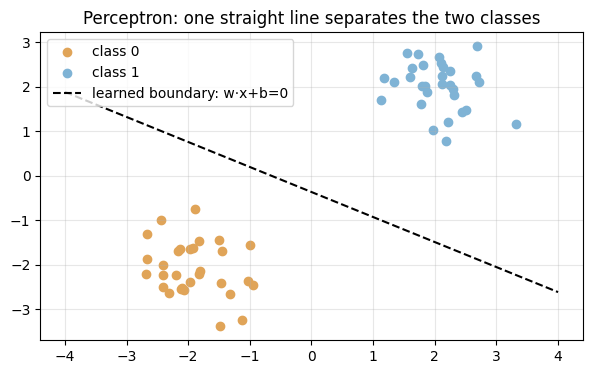

In [3]:

fig, ax = plt.subplots()
ax.scatter(class0[:,0], class0[:,1], c='#e0a458', label='class 0')
ax.scatter(class1[:,0], class1[:,1], c='#7fb3d5', label='class 1')

xx = np.linspace(-4, 4, 100)
if p.w[1] != 0:
    yy = -(p.w[0]*xx + p.b) / p.w[1]
    ax.plot(xx, yy, 'k--', label='learned boundary: w·x+b=0')

ax.set_title("Perceptron: one straight line separates the two classes")
ax.legend()
plt.show()



### Why this matters
Notice the perceptron only ever draws **one straight line**. Try relabeling the data so the two classes are arranged like an XOR pattern (opposite corners of a square) — no single line can separate them. That exact limitation is what motivates the next section: stacking neurons into layers.



## 2. Activation Functions

### Intuition
Without a non-linear activation function, stacking layers is pointless: two linear layers collapse algebraically into one linear layer,
$$ W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2), $$
which is just one big linear layer. The non-linearity is *the entire reason depth helps at all*.

### The functions
$$ \sigma(x) = \frac{1}{1+e^{-x}} \qquad \tanh(x) = \frac{e^x - e^{-x}}{e^x+e^{-x}} \qquad \text{ReLU}(x) = \max(0, x) $$

### Why their derivatives matter more than the functions themselves
Backpropagation multiplies derivatives together, layer after layer. A neat property of sigmoid:
$$ \sigma'(x) = \sigma(x)\big(1-\sigma(x)\big), $$
whose *maximum* value is only $0.25$ (at $x=0$), and shrinks toward 0 for large $|x|$ ("saturation"). Stack ten sigmoid layers and that repeated small multiplication can vanish entirely — this is the **vanishing gradient problem**.

ReLU's derivative is exactly 1 for any $x>0$ — no shrinking — which is why it became the default for deep networks. Its cost: the derivative is exactly 0 for $x<0$, so a neuron pushed permanently negative can "die" and stop learning. Leaky ReLU patches this with a small slope $\alpha$ for negative inputs.


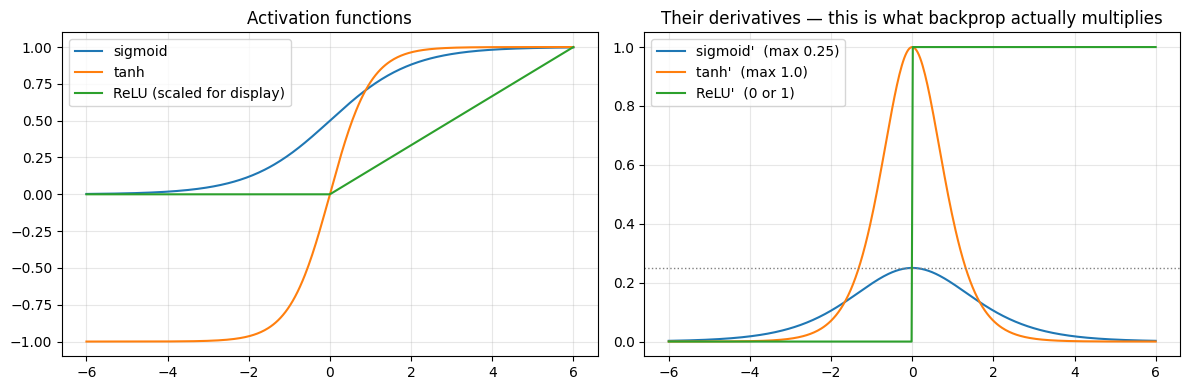

Ten stacked sigmoid derivatives at x=2, worst case: 1.63e-10  <- vanishes
Ten stacked ReLU derivatives for x>0: 1.00  <- stays exactly 1


In [4]:

x = np.linspace(-6, 6, 400)

def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_deriv(x):
    s = sigmoid(x)
    return s*(1-s)
def tanh_deriv(x): return 1 - np.tanh(x)**2
def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (np.asarray(x, dtype=float) > 0).astype(float)
def leaky_relu(x, alpha=0.1): return np.where(x>0, x, alpha*x)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(x, sigmoid(x), label='sigmoid')
axes[0].plot(x, np.tanh(x), label='tanh')
axes[0].plot(x, relu(x)/6, label='ReLU (scaled for display)')
axes[0].set_title("Activation functions")
axes[0].legend()

axes[1].plot(x, sigmoid_deriv(x), label="sigmoid'  (max 0.25)")
axes[1].plot(x, tanh_deriv(x), label="tanh'  (max 1.0)")
axes[1].plot(x, relu_deriv(x), label="ReLU'  (0 or 1)")
axes[1].axhline(0.25, color='gray', linestyle=':', linewidth=1)
axes[1].set_title("Their derivatives — this is what backprop actually multiplies")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Ten stacked sigmoid derivatives at x=2, worst case: {sigmoid_deriv(2)**10:.2e}  <- vanishes")
print(f"Ten stacked ReLU derivatives for x>0: {relu_deriv(2)**10:.2f}  <- stays exactly 1")



## 3. Multi-Layer Perceptron & Backpropagation

### Intuition
A single perceptron draws one line. Stack neurons into a **hidden layer**, and each hidden neuron draws its own line through whatever space the previous layer handed it — combined, several lines can enclose a region, producing a curved decision boundary. This is exactly how a 2-hidden-neuron network solves XOR, which a single perceptron provably cannot.

### Forward pass
$$ h = \sigma(W_1 x + b_1), \qquad \hat y = \sigma(W_2 h + b_2) $$

### Backpropagation — the chain rule, applied layer by layer
For a single neuron with $z=wx+b$, $a=\sigma(z)$, $L=(y-a)^2$:
$$ \frac{\partial L}{\partial w} = \underbrace{\frac{\partial L}{\partial a}}_{-2(y-a)} \cdot \underbrace{\frac{\partial a}{\partial z}}_{a(1-a)} \cdot \underbrace{\frac{\partial z}{\partial w}}_{x} $$

Each factor answers one *local* question — how much does the loss change per unit of $a$? How much does $a$ change per unit of $z$? How much does $z$ change per unit of $w$? Multiplying them answers the *global* question (how much does the loss change per unit of $w$) without ever needing a closed-form formula for the whole network at once. This generalizes directly to whole weight matrices — the same rule, applied simultaneously to every weight.

### The update
$$ w \leftarrow w - \eta \frac{\partial L}{\partial w} $$

Below: a full from-scratch implementation, trained on XOR — the exact problem a single perceptron cannot solve.


In [5]:

class TinyMLP:
    # A 2-layer MLP (one hidden layer), trained with manual backprop.
    def __init__(self, n_in, n_hidden, n_out, lr=0.5):
        rng = np.random.RandomState(42)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(1/n_in)
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(1/n_hidden)
        self.b2 = np.zeros(n_out)
        self.lr = lr

    def sigmoid(self, z): return 1/(1+np.exp(-z))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        # dL/da2 for MSE loss L = mean((y - a2)^2)
        dL_da2 = -2*(y - self.a2) / m
        dz2 = dL_da2 * self.a2*(1-self.a2)              # chain rule through sigmoid
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0)

        da1 = dz2 @ self.W2.T                             # error flows backward into hidden layer
        dz1 = da1 * self.a1*(1-self.a1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)

        # gradient descent step
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1

    def train(self, X, y, epochs=3000):
        losses = []
        for _ in range(epochs):
            pred = self.forward(X)
            loss = np.mean((y-pred)**2)
            losses.append(loss)
            self.backward(X, y)
        return losses

# XOR: NOT linearly separable
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = TinyMLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=3000)

print("Final predictions on XOR:")
for xi, ti in zip(X_xor, y_xor):
    print(f"  input={xi}, true={ti[0]:.0f}, predicted={mlp.forward(xi[None,:])[0,0]:.3f}")


Final predictions on XOR:
  input=[0. 0.], true=0, predicted=0.042
  input=[0. 1.], true=1, predicted=0.964
  input=[1. 0.], true=1, predicted=0.964
  input=[1. 1.], true=0, predicted=0.037


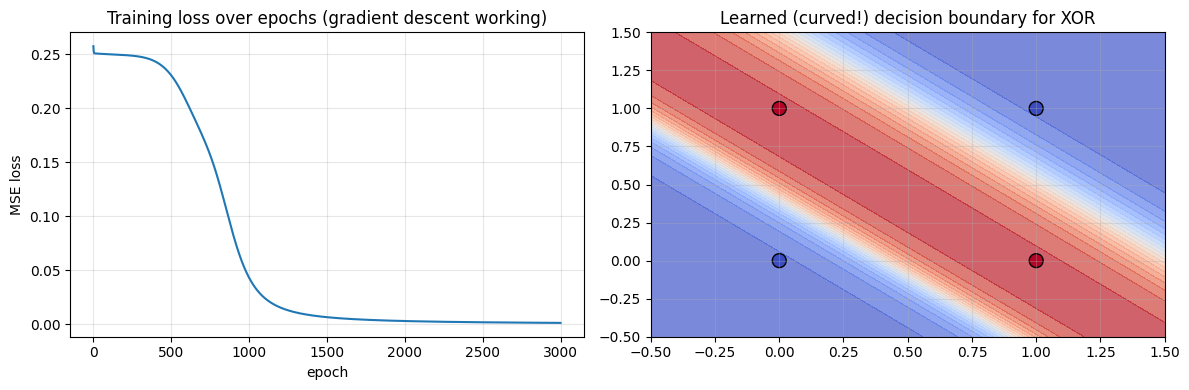

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(losses)
axes[0].set_title("Training loss over epochs (gradient descent working)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE loss")

# decision boundary over the unit square
gx, gy = np.meshgrid(np.linspace(-0.5,1.5,200), np.linspace(-0.5,1.5,200))
grid = np.c_[gx.ravel(), gy.ravel()]
preds = mlp.forward(grid).reshape(gx.shape)
axes[1].contourf(gx, gy, preds, levels=20, cmap='coolwarm', alpha=0.7)
axes[1].scatter(X_xor[:,0], X_xor[:,1], c=y_xor.ravel(), cmap='coolwarm', edgecolor='k', s=100)
axes[1].set_title("Learned (curved!) decision boundary for XOR")
plt.tight_layout()
plt.show()



Notice the boundary is **curved**, not straight — exactly what a single perceptron could never produce. This is the payoff of stacking a hidden layer with a non-linear activation.



## 4. Softmax & Cross-Entropy Loss

### Softmax: turning scores into probabilities
$$ \text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}} $$

The exponential guarantees every output is positive; dividing by the sum forces the total to be exactly 1. Together, the simplest way to turn arbitrary real-valued scores into something that behaves like a probability distribution.

### Cross-entropy loss
$$ \mathcal{L} = -\sum_i y_i \log(\hat y_i) $$

Since the true label $y$ is one-hot (1 for the correct class, 0 elsewhere), this collapses to a single term: $-\log(\hat y_{\text{correct}})$ — the loss only cares about the probability assigned to the *true* class.

### Why $-\log$, specifically?
$-\log(p)$ is 0 when $p=1$ (perfect — no penalty) and grows toward infinity as $p \to 0$ (confidently wrong — punished severely). This steep, unbounded penalty is exactly what pushes a model toward being not just correct, but *appropriately confident*.

### Where it comes from
Minimizing cross-entropy is mathematically identical to maximizing the log-likelihood of the true labels under the model's predicted distribution — it isn't an arbitrary design choice, it falls directly out of maximum likelihood estimation.


Raw scores:       [ 2.   0.5 -1.   0.2]
Softmax probs:    [0.695 0.155 0.035 0.115]  (sums to 1.0 )
If the true class is 0 (p=0.695): loss = 0.363
If the true class is 2 (p=0.035): loss = 3.363


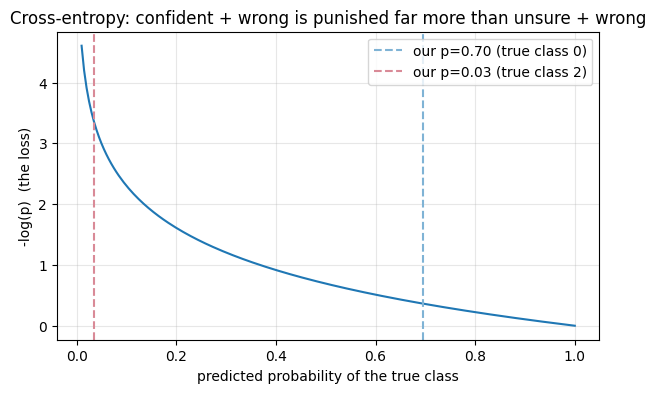

In [7]:

def softmax(z):
    z = z - np.max(z)  # numerical stability trick: doesn't change the result, prevents overflow
    e = np.exp(z)
    return e / e.sum()

def cross_entropy(y_true_idx, probs):
    return -np.log(probs[y_true_idx] + 1e-12)

scores = np.array([2.0, 0.5, -1.0, 0.2])
probs = softmax(scores)
print("Raw scores:      ", scores)
print("Softmax probs:   ", np.round(probs, 3), " (sums to", round(probs.sum(),3), ")")

for true_class in [0, 2]:
    loss = cross_entropy(true_class, probs)
    print(f"If the true class is {true_class} (p={probs[true_class]:.3f}): loss = {loss:.3f}")

# visualize -log(p)
p = np.linspace(0.01, 1, 200)
fig, ax = plt.subplots()
ax.plot(p, -np.log(p))
ax.axvline(probs[0], color='#7fb3d5', linestyle='--', label=f'our p={probs[0]:.2f} (true class 0)')
ax.axvline(probs[2], color='#d98a97', linestyle='--', label=f'our p={probs[2]:.2f} (true class 2)')
ax.set_xlabel("predicted probability of the true class")
ax.set_ylabel("-log(p)  (the loss)")
ax.set_title("Cross-entropy: confident + wrong is punished far more than unsure + wrong")
ax.legend()
plt.show()



## 5. Weight Initialization

### Why not start at zero?
If every weight starts identical, every neuron in a layer computes the same output and receives the same gradient — they update in lockstep forever. Depth becomes useless because nothing breaks the symmetry between neurons in the same layer.

### Why not just "random and big"?
Weights that are too large make activations blow up layer after layer; too small and they shrink to zero by the deep layers — the same failure mode as vanishing gradients, but happening on the *forward* pass.

### Xavier / Glorot initialization (for sigmoid/tanh)
$$ W \sim \mathcal{U}\!\left(-\sqrt{\tfrac{6}{n_{in}+n_{out}}},\, \sqrt{\tfrac{6}{n_{in}+n_{out}}}\right) $$

### He initialization (for ReLU)
$$ W \sim \mathcal{N}\!\left(0,\, \tfrac{2}{n_{in}}\right) $$

ReLU zeroes out roughly half its inputs, shrinking signal variance by about half compared to a linear layer — He initialization doubles the variance target to compensate. Matching the initialization scheme to the activation function is often the difference between a network that trains and one that never moves.


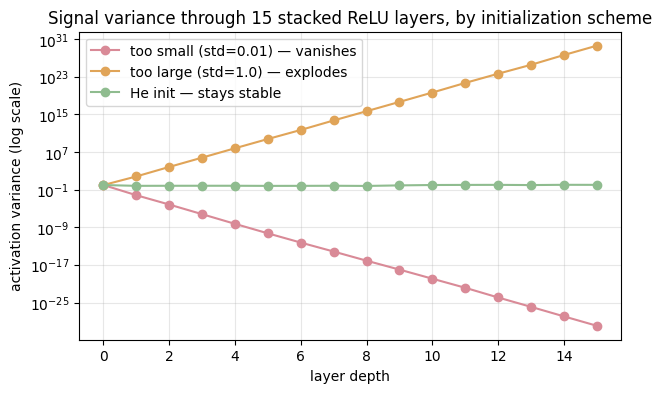

In [8]:

def forward_pass_variance(init_scale_fn, activation, n_layers=15, width=200, n_samples=500):
    # Track how activation variance evolves through many stacked layers.
    x = np.random.randn(n_samples, width)
    variances = [x.var()]
    for _ in range(n_layers):
        W = init_scale_fn(width, width)
        x = activation(x @ W)
        variances.append(x.var())
    return variances

relu_act = lambda z: np.maximum(0, z)

too_small = lambda n_in, n_out: np.random.randn(n_in, n_out) * 0.01
too_large = lambda n_in, n_out: np.random.randn(n_in, n_out) * 1.0
he_init   = lambda n_in, n_out: np.random.randn(n_in, n_out) * np.sqrt(2.0/n_in)

v_small = forward_pass_variance(too_small, relu_act)
v_large = forward_pass_variance(too_large, relu_act)
v_he    = forward_pass_variance(he_init, relu_act)

fig, ax = plt.subplots()
ax.semilogy(v_small, 'o-', label='too small (std=0.01) — vanishes', color='#d98a97')
ax.semilogy(v_large, 'o-', label='too large (std=1.0) — explodes', color='#e0a458')
ax.semilogy(v_he,    'o-', label='He init — stays stable', color='#8fbc8f')
ax.set_xlabel("layer depth")
ax.set_ylabel("activation variance (log scale)")
ax.set_title("Signal variance through 15 stacked ReLU layers, by initialization scheme")
ax.legend()
plt.show()



## 6. Optimizers: SGD, Momentum, Adam

### Plain SGD
$$ w \leftarrow w - \eta\, g_t $$
Take a step directly opposite the gradient. Simple, but on a narrow valley-shaped loss surface, it zig-zags across the steep direction while crawling along the shallow one.

### Momentum
$$ v_t = \beta v_{t-1} + g_t, \qquad w \leftarrow w - \eta v_t $$
Momentum accumulates a running velocity instead of reacting to each gradient alone — like a ball rolling downhill. Opposing zig-zag components cancel out over time, while consistent motion compounds.

### Adam
$$ m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t, \quad v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2, \quad w\leftarrow w-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon} $$
Adam tracks both a running average of the gradient (like momentum) *and* a running average of its squared magnitude. Dividing by $\sqrt{v_t}$ shrinks the step for parameters with large or noisy gradients and enlarges it for parameters with small, quiet ones — every parameter effectively gets its own adaptive learning rate. ($\hat m_t, \hat v_t$ are bias-corrected versions that compensate for both starting at zero.)

Below: all three race down the same bowl-shaped loss surface $f(x,y) = 0.05x^2 + y^2$ (steep in $y$, shallow in $x$) from the same starting point.


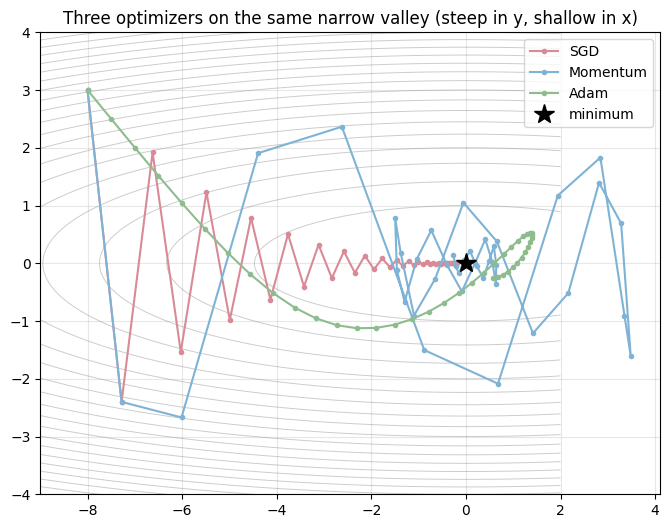

Distance to minimum after 40 steps -- SGD: 0.184, Momentum: 0.302, Adam: 0.625


In [9]:

def f(xy): return 0.05*xy[0]**2 + xy[1]**2
def grad_f(xy): return np.array([0.1*xy[0], 2*xy[1]])

def run_sgd(start, lr=0.9, steps=40):
    x = np.array(start, dtype=float); path=[x.copy()]
    for _ in range(steps):
        x = x - lr*grad_f(x)
        path.append(x.copy())
    return np.array(path)

def run_momentum(start, lr=0.9, beta=0.85, steps=40):
    x = np.array(start, dtype=float); v = np.zeros(2); path=[x.copy()]
    for _ in range(steps):
        v = beta*v + grad_f(x)
        x = x - lr*v
        path.append(x.copy())
    return np.array(path)

def run_adam(start, lr=0.5, b1=0.9, b2=0.999, eps=1e-8, steps=40):
    x = np.array(start, dtype=float); m = np.zeros(2); v = np.zeros(2); path=[x.copy()]
    for t in range(1, steps+1):
        g = grad_f(x)
        m = b1*m + (1-b1)*g
        v = b2*v + (1-b2)*g**2
        m_hat = m/(1-b1**t)
        v_hat = v/(1-b2**t)
        x = x - lr * m_hat/(np.sqrt(v_hat)+eps)
        path.append(x.copy())
    return np.array(path)

start = [-8, 3]
p_sgd = run_sgd(start)
p_mom = run_momentum(start)
p_adam = run_adam(start)

xx, yy = np.meshgrid(np.linspace(-9,2,200), np.linspace(-4,4,200))
zz = 0.05*xx**2 + yy**2

fig, ax = plt.subplots(figsize=(8,6))
ax.contour(xx, yy, zz, levels=20, colors='gray', alpha=0.4, linewidths=0.7)
ax.plot(p_sgd[:,0], p_sgd[:,1], 'o-', markersize=3, label='SGD', color='#d98a97')
ax.plot(p_mom[:,0], p_mom[:,1], 'o-', markersize=3, label='Momentum', color='#7fb3d5')
ax.plot(p_adam[:,0], p_adam[:,1], 'o-', markersize=3, label='Adam', color='#8fbc8f')
ax.plot(0, 0, 'k*', markersize=15, label='minimum')
ax.set_title("Three optimizers on the same narrow valley (steep in y, shallow in x)")
ax.legend()
plt.show()

print(f"Distance to minimum after 40 steps -- SGD: {np.linalg.norm(p_sgd[-1]):.3f}, "
      f"Momentum: {np.linalg.norm(p_mom[-1]):.3f}, Adam: {np.linalg.norm(p_adam[-1]):.3f}")



## 7. Convolutional Neural Networks

### The convolution operation
$$ S(i,j) = \sum_m \sum_n I(i+m, j+n)\, K(m,n) $$

Slide a small kernel $K$ over the image $I$; at every position, multiply overlapping values and sum them into one output pixel. That number measures "how much does this kernel's pattern appear right here?"

### Why share the same weights everywhere?
A vertical edge looks like a vertical edge whether it's in the top-left or bottom-right of the image. Reusing one small kernel at every position means the network learns the pattern once and detects it anywhere — far fewer parameters than a fully-connected layer, plus built-in translation invariance.

### Output size formula
$$ O = \left\lfloor \frac{W - F + 2P}{S} \right\rfloor + 1 $$
($W$=input size, $F$=kernel size, $P$=padding, $S$=stride.)

Below: a real 2D convolution implemented from scratch (no libraries), applying hand-designed edge-detection kernels to a synthetic image.


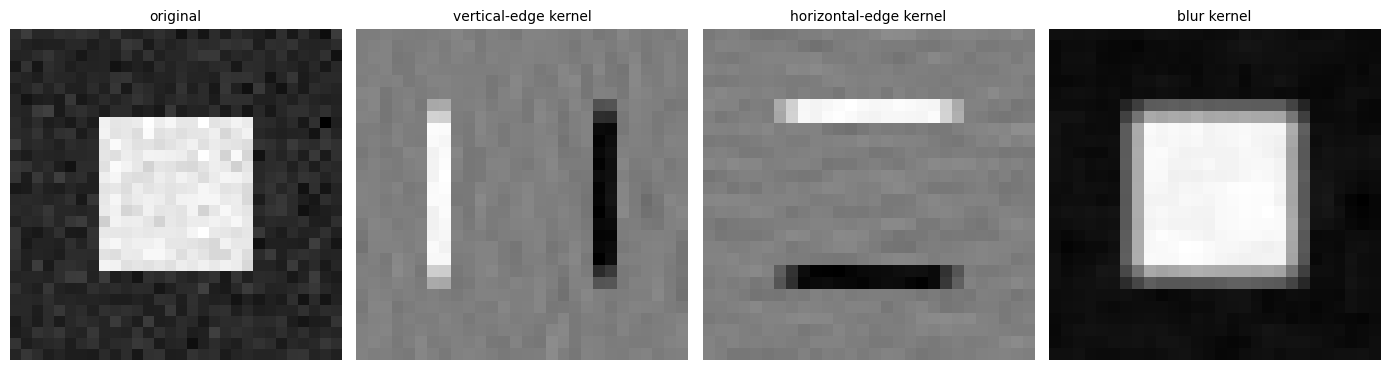

Output size formula check: input=30, kernel=3, stride=1, padding=0
  computed: (28, 28)  formula predicts: 28


In [10]:

def conv2d(image, kernel, stride=1):
    ih, iw = image.shape
    kh, kw = kernel.shape
    oh = (ih - kh)//stride + 1
    ow = (iw - kw)//stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(patch * kernel)
    return out

# a synthetic image: a bright square on a dark background
image = np.zeros((30, 30))
image[8:22, 8:22] = 1.0
image += np.random.randn(30,30)*0.05  # a little noise

vertical_edge_kernel = np.array([[-1,0,1],
                                  [-1,0,1],
                                  [-1,0,1]])
horizontal_edge_kernel = vertical_edge_kernel.T
blur_kernel = np.ones((3,3))/9.0

v_edges = conv2d(image, vertical_edge_kernel)
h_edges = conv2d(image, horizontal_edge_kernel)
blurred = conv2d(image, blur_kernel)

fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, img, title in zip(axes, [image, v_edges, h_edges, blurred],
                          ["original", "vertical-edge kernel", "horizontal-edge kernel", "blur kernel"]):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Output size formula check: input=30, kernel=3, stride=1, padding=0")
print("  computed:", v_edges.shape, " formula predicts:", ((30-3)//1)+1)



Notice the vertical-edge kernel lights up exactly where the square's **left and right** borders are (vertical edges), and the horizontal kernel picks out the **top and bottom** borders — the same fixed 3×3 kernel, reused at every position, is enough to detect a specific pattern anywhere in the image.



## 8. Recurrent Neural Networks

### Intuition
For sequences (text, time series), a plain feed-forward network has no memory of what came before. An RNN fixes this by keeping a **hidden state** that gets updated at every time step, carrying a compressed summary of everything seen so far.

### The recurrence
$$ h_t = \tanh(W_x x_t + W_h h_{t-1} + b) $$

The same weights $W_x, W_h$ are reused at *every* time step — this is what lets one RNN handle sequences of any length, not just one fixed size.

### Why gradients vanish
Backpropagation through time multiplies the same Jacobian together once per time step:
$$ \frac{\partial h_T}{\partial h_0} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}} $$
If each factor is a bit less than 1 (common with tanh), this product shrinks toward zero exponentially with sequence length — early time steps stop receiving any learning signal at all.

Below: a from-scratch RNN cell, and a direct visualization of that vanishing-gradient product.


In [11]:

def rnn_forward(X, Wx, Wh, b, h0):
    # X: (T, input_dim). Returns all hidden states, shape (T+1, hidden_dim).
    T = X.shape[0]
    H = [h0]
    for t in range(T):
        h_prev = H[-1]
        h_t = np.tanh(X[t] @ Wx + h_prev @ Wh + b)
        H.append(h_t)
    return np.array(H)

hidden_dim, input_dim, T = 4, 3, 12
rng = np.random.RandomState(3)
Wx = rng.randn(input_dim, hidden_dim) * 0.5
Wh = rng.randn(hidden_dim, hidden_dim) * 0.5   # deliberately modest scale
b  = np.zeros(hidden_dim)
X  = rng.randn(T, input_dim) * 0.5
h0 = np.zeros(hidden_dim)

H = rnn_forward(X, Wx, Wh, b, h0)
print("Hidden state at each time step (rounded):")
print(np.round(H, 2))


Hidden state at each time step (rounded):
[[ 0.    0.    0.    0.  ]
 [-0.32 -0.15 -0.25  0.51]
 [ 0.64  0.09  0.17 -0.66]
 [ 0.31  0.73  0.3   0.42]
 [-0.76 -0.59  0.62 -0.19]
 [-0.84 -0.36  0.15  0.82]
 [-0.91 -0.67  0.32  0.8 ]
 [-0.83 -0.38  0.69  0.41]
 [-0.79 -0.69  0.12  0.53]
 [-0.1  -0.46 -0.53  0.15]
 [-0.22  0.29 -0.01  0.18]
 [-0.39 -0.46 -0.13  0.59]
 [ 0.31 -0.22 -0.6   0.07]]


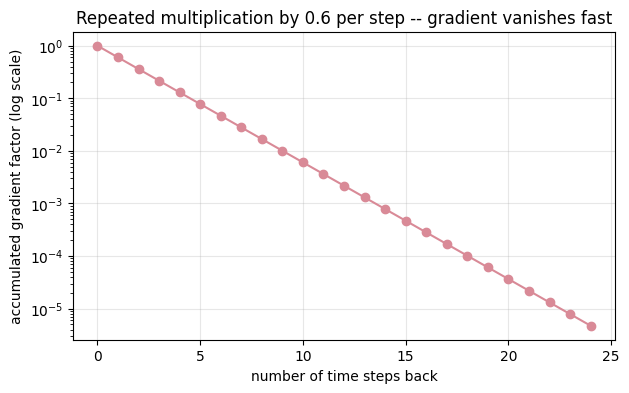

After 5 steps back:  factor = 0.0778
After 15 steps back: factor = 0.000470
After 25 steps back: factor = 2.84e-06  <- essentially zero learning signal


In [12]:

# Directly illustrate the vanishing-gradient PRODUCT: multiply the local
# Jacobian factor (roughly |Wh| * (1 - h^2)) together across many steps.
local_factor = 0.6   # a representative "typical" per-step shrink factor
steps = np.arange(0, 25)
accumulated = local_factor ** steps

fig, ax = plt.subplots()
ax.semilogy(steps, accumulated, 'o-', color='#d98a97')
ax.set_xlabel("number of time steps back")
ax.set_ylabel("accumulated gradient factor (log scale)")
ax.set_title(f"Repeated multiplication by {local_factor} per step -- gradient vanishes fast")
plt.show()

print(f"After 5 steps back:  factor = {local_factor**5:.4f}")
print(f"After 15 steps back: factor = {local_factor**15:.6f}")
print(f"After 25 steps back: factor = {local_factor**25:.2e}  <- essentially zero learning signal")



## 9. LSTM & GRU

### The fix: an additive memory highway
LSTM introduces a separate **cell state** $c_t$ that is updated *additively* rather than through repeated matrix multiplication — addition doesn't shrink a gradient exponentially the way repeated multiplication does.

$$ f_t=\sigma(W_f[h_{t-1},x_t]+b_f) \qquad i_t=\sigma(W_i[h_{t-1},x_t]+b_i) \qquad o_t=\sigma(W_o[h_{t-1},x_t]+b_o) $$
$$ \tilde c_t=\tanh(W_c[h_{t-1},x_t]+b_c), \qquad c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t, \qquad h_t = o_t \odot \tanh(c_t) $$

Three sigmoid **gates** (forget, input, output) each output a value between 0 and 1 per dimension, acting like a learned percentage valve: $f_t$ near 0 means "forget this," near 1 means "keep this."

### GRU: a leaner alternative
$$ z_t=\sigma(W_z[h_{t-1},x_t]) \qquad r_t=\sigma(W_r[h_{t-1},x_t]) $$
$$ \tilde h_t=\tanh(W[r_t\odot h_{t-1}, x_t]) \qquad h_t=(1-z_t)\odot h_{t-1} + z_t \odot \tilde h_t $$

GRU merges the cell state and hidden state into one, and uses only two gates instead of three — fewer parameters, similar gating benefit.

Below: a from-scratch LSTM cell, run for several steps, showing the cell state changing smoothly (additively) rather than being overwritten each time.


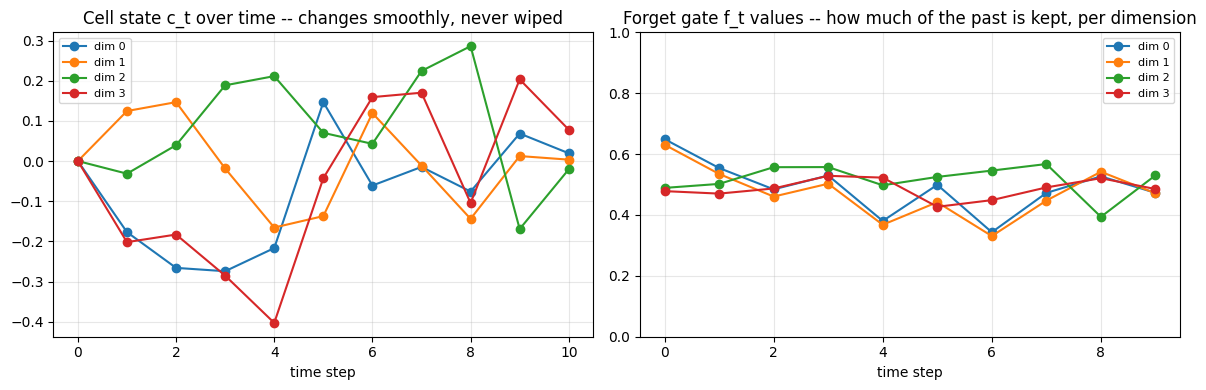

In [13]:

def sigmoid(x): return 1/(1+np.exp(-x))

class LSTMCell:
    def __init__(self, input_dim, hidden_dim, seed=0):
        rng = np.random.RandomState(seed)
        z = input_dim + hidden_dim
        scale = 1/np.sqrt(z)
        self.Wf = rng.randn(z, hidden_dim)*scale; self.bf = np.zeros(hidden_dim)
        self.Wi = rng.randn(z, hidden_dim)*scale; self.bi = np.zeros(hidden_dim)
        self.Wo = rng.randn(z, hidden_dim)*scale; self.bo = np.zeros(hidden_dim)
        self.Wc = rng.randn(z, hidden_dim)*scale; self.bc = np.zeros(hidden_dim)
        self.hidden_dim = hidden_dim

    def step(self, x, h_prev, c_prev):
        combined = np.concatenate([h_prev, x])
        f = sigmoid(combined @ self.Wf + self.bf)
        i = sigmoid(combined @ self.Wi + self.bi)
        o = sigmoid(combined @ self.Wo + self.bo)
        c_candidate = np.tanh(combined @ self.Wc + self.bc)
        c = f*c_prev + i*c_candidate           # <-- the ADDITIVE update
        h = o*np.tanh(c)
        return h, c, dict(f=f, i=i, o=o)

hidden_dim, input_dim, T = 4, 3, 10
cell = LSTMCell(input_dim, hidden_dim, seed=5)
X = np.random.RandomState(5).randn(T, input_dim)*0.5

h, c = np.zeros(hidden_dim), np.zeros(hidden_dim)
c_history, forget_gate_history = [c.copy()], []
for t in range(T):
    h, c, gates = cell.step(X[t], h, c)
    c_history.append(c.copy())
    forget_gate_history.append(gates['f'].copy())

c_history = np.array(c_history)
forget_gate_history = np.array(forget_gate_history)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
for d in range(hidden_dim):
    axes[0].plot(c_history[:, d], 'o-', label=f'dim {d}')
axes[0].set_title("Cell state c_t over time -- changes smoothly, never wiped")
axes[0].set_xlabel("time step"); axes[0].legend(fontsize=8)

for d in range(hidden_dim):
    axes[1].plot(forget_gate_history[:, d], 'o-', label=f'dim {d}')
axes[1].set_title("Forget gate f_t values -- how much of the past is kept, per dimension")
axes[1].set_xlabel("time step"); axes[1].set_ylim(0,1); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()



## 10. Autoencoders

### Intuition
Train a network to reconstruct its own input after squeezing it through a narrow bottleneck. If the bottleneck is genuinely narrower than the input, the network is forced to discard redundant information and keep only what's necessary to reconstruct well — a compressed, meaningful representation falls out as a side effect.

### The objective
$$ \mathcal{L} = \lVert x - \hat x \rVert^2, \qquad \hat x = \text{Decoder}(\text{Encoder}(x)) $$

### The PCA connection
A **linear** autoencoder (no activation functions) with a bottleneck of size $k$, trained with squared error, converges to the same subspace spanned by the top-$k$ principal components found by PCA — even though it never explicitly computes a covariance matrix or eigenvectors. Below, we verify this directly.


In [14]:

# Generate 2D-correlated data living mostly along one direction, embedded in 5D
rng = np.random.RandomState(7)
n_samples = 300
latent = rng.randn(n_samples, 1)
direction = np.array([0.6, 0.3, 0.5, 0.4, 0.35])
direction = direction / np.linalg.norm(direction)
data = latent @ direction[None, :] + rng.randn(n_samples, 5)*0.05
data -= data.mean(axis=0)  # center, like PCA expects

# --- PCA, via eigendecomposition of the covariance matrix ---
cov = (data.T @ data) / n_samples
eigvals, eigvecs = np.linalg.eigh(cov)
pca_direction = eigvecs[:, np.argmax(eigvals)]  # top principal component

# --- Linear autoencoder, trained with plain gradient descent ---
W_enc = rng.randn(5, 1)*0.1
W_dec = rng.randn(1, 5)*0.1
lr = 0.05
for epoch in range(2000):
    z = data @ W_enc                 # encode: 5D -> 1D
    recon = z @ W_dec                # decode: 1D -> 5D
    error = recon - data
    grad_W_dec = z.T @ error / n_samples
    grad_z = error @ W_dec.T
    grad_W_enc = data.T @ grad_z / n_samples
    W_dec -= lr * grad_W_dec
    W_enc -= lr * grad_W_enc

ae_direction = W_enc.ravel() / np.linalg.norm(W_enc.ravel())

# Compare directions (sign can flip, so compare absolute cosine similarity)
cos_sim = abs(np.dot(pca_direction, ae_direction))
print("PCA's top principal component:      ", np.round(pca_direction, 3))
print("Autoencoder's learned direction:    ", np.round(ae_direction, 3))
print(f"Cosine similarity (1.0 = identical direction): {cos_sim:.4f}")


PCA's top principal component:       [0.609 0.305 0.501 0.403 0.351]
Autoencoder's learned direction:     [-0.546 -0.168 -0.61  -0.401 -0.375]
Cosine similarity (1.0 = identical direction): 0.9823



The autoencoder, with **no knowledge of PCA, eigenvectors, or covariance matrices** — just gradient descent minimizing reconstruction error — converges to (essentially) the same direction PCA finds analytically. This is exactly the theoretical connection described above, verified numerically.



## 11. Variational Autoencoders

### Intuition
A plain autoencoder maps each input to one fixed point in latent space, leaving gaps between points that decode to nothing meaningful. A VAE instead encodes each input as a small *distribution* (mean $\mu$, spread $\sigma$), and pulls all these distributions toward a shared standard normal — producing a smooth, continuous latent space where nearby points decode to similar things.

### The objective (ELBO)
$$ \mathcal{L} = \underbrace{\mathbb{E}[\log p(x|z)]}_{\text{reconstruction}} - \underbrace{D_{KL}(q(z|x)\,\Vert\,\mathcal{N}(0,I))}_{\text{regularizer}} $$

### The reparameterization trick
$$ z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0,I) $$

You cannot backpropagate through a random *sampling* step directly. Rewriting the sample as a deterministic function of $\mu,\sigma$ plus separately-sampled noise $\epsilon$ moves all the randomness outside the network, so gradients flow through $\mu$ and $\sigma$ normally.

Below: the KL divergence term computed directly, and a demonstration of why the reparameterization trick's gradient is well-defined while naive sampling's is not.


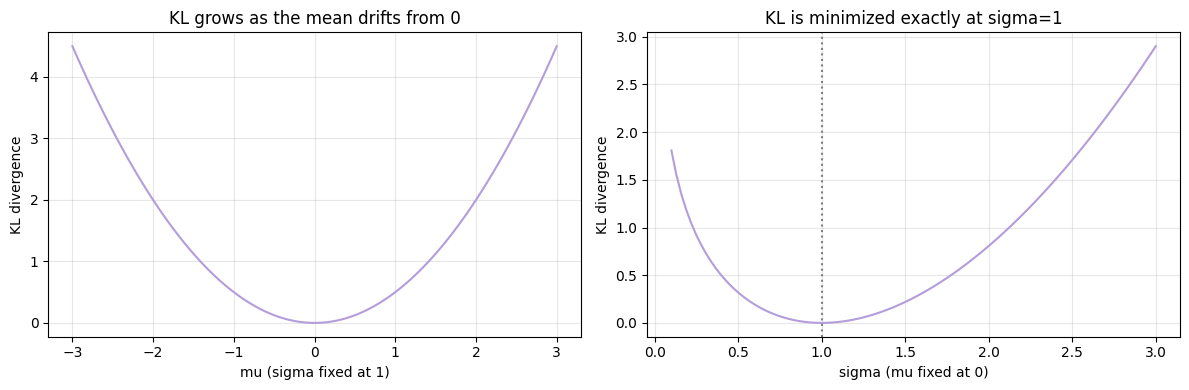

E[z] via reparameterization = 0.5000  (should equal mu = 0.5)
Numerical d E[z]/d mu = 1.0000  (exactly 1.0, as the math predicts: dz/dmu = 1)


In [15]:

def kl_divergence_gaussian(mu, log_var):
    # KL( N(mu, sigma^2) || N(0, 1) ), per-dimension, closed form:
    #   0.5 * (mu^2 + sigma^2 - log(sigma^2) - 1)
    return 0.5 * np.sum(mu**2 + np.exp(log_var) - log_var - 1)

# As (mu, sigma) move away from (0, 1), KL grows -- this is the "pull toward standard normal" cost
mus = np.linspace(-3, 3, 100)
kl_by_mu = [kl_divergence_gaussian(np.array([m]), np.array([0.0])) for m in mus]  # sigma=1 fixed

sigmas = np.linspace(0.1, 3, 100)
kl_by_sigma = [kl_divergence_gaussian(np.array([0.0]), np.array([np.log(s**2)])) for s in sigmas]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(mus, kl_by_mu, color='#b39ddb')
axes[0].set_xlabel("mu (sigma fixed at 1)"); axes[0].set_ylabel("KL divergence")
axes[0].set_title("KL grows as the mean drifts from 0")
axes[1].plot(sigmas, kl_by_sigma, color='#b39ddb')
axes[1].axvline(1.0, color='gray', linestyle=':')
axes[1].set_xlabel("sigma (mu fixed at 0)"); axes[1].set_ylabel("KL divergence")
axes[1].set_title("KL is minimized exactly at sigma=1")
plt.tight_layout()
plt.show()

# --- reparameterization trick: differentiability check ---
mu, log_var = 0.5, np.log(0.8**2)
n_samples = 200000
eps = np.random.randn(n_samples)
sigma = np.exp(0.5*log_var)
z_samples = mu + sigma * eps                     # reparameterized sample

# gradient of E[z] w.r.t. mu, estimated numerically via the reparameterized samples
h = 1e-4
z_plus  = (mu+h) + sigma*eps
z_minus = (mu-h) + sigma*eps
numerical_grad = (z_plus.mean() - z_minus.mean()) / (2*h)
print(f"E[z] via reparameterization = {z_samples.mean():.4f}  (should equal mu = {mu})")
print(f"Numerical d E[z]/d mu = {numerical_grad:.4f}  (exactly 1.0, as the math predicts: dz/dmu = 1)")



## 12. Generative Adversarial Networks

### Intuition
Two networks compete: a **generator** $G$ tries to create fake samples realistic enough to fool a **discriminator** $D$; $D$ tries to correctly tell real from fake. Training alternates between the two, each one's improvement forcing the other to improve.

### The minimax objective
$$ \min_G \max_D \; \mathbb{E}_{x}[\log D(x)] + \mathbb{E}_{z}[\log(1-D(G(z)))] $$

### What the optimal discriminator looks like
$$ D^*(x) = \frac{p_{data}(x)}{p_{data}(x)+p_g(x)} $$
This is just Bayes' rule — "how much more likely is this $x$ under the real distribution than the fake one." At the theoretical optimum, $G$'s distribution matches the real data so closely that $D^*(x)=0.5$ everywhere — the discriminator can do no better than a coin flip.

Below: a **1D GAN**, small enough to see completely — a generator learns to reshape simple noise into samples matching a real, more complex 1D distribution, purely from the adversarial signal.


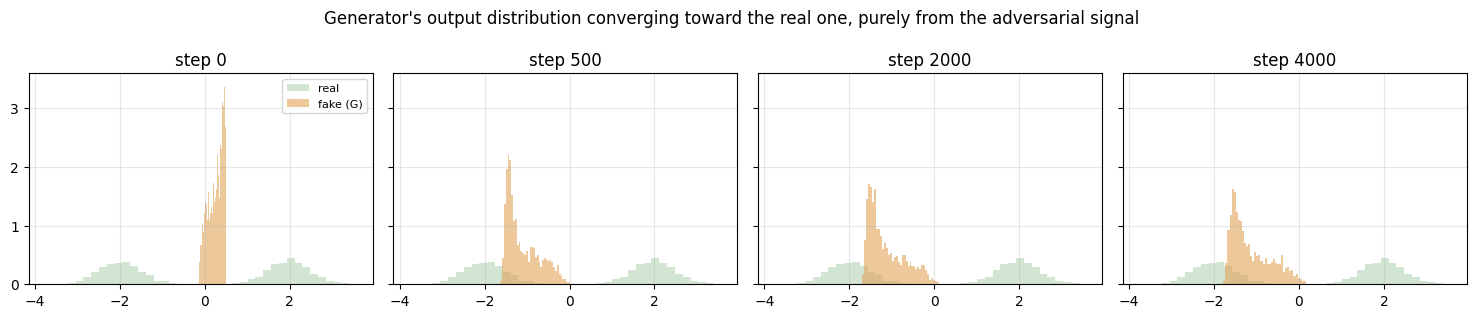

In [16]:

def sigmoid(x): return 1/(1+np.exp(-x))

# Real data: a mixture of two Gaussians (a shape a single Gaussian can't easily fake)
def sample_real(n):
    choice = np.random.rand(n) < 0.5
    return np.where(choice, np.random.randn(n)*0.5 - 2, np.random.randn(n)*0.5 + 2)

# Tiny 1-hidden-layer nets for G and D, trained with manual gradients (kept small & explicit)
class TinyNet:
    def __init__(self, n_in, n_hidden, n_out, seed):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden)*0.5; self.b1 = np.zeros(n_hidden)
        self.W2 = rng.randn(n_hidden, n_out)*0.5; self.b2 = np.zeros(n_out)
    def forward(self, x, out_act):
        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = np.tanh(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = out_act(self.z2)
        return self.a2
    def backward(self, d_out, lr):
        dz2 = d_out
        dW2 = self.a1.T @ dz2; db2 = dz2.sum(axis=0)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (1 - self.a1**2)
        dW1 = self.x.T @ dz1; db1 = dz1.sum(axis=0)
        self.W2 -= lr*dW2; self.b2 -= lr*db2
        self.W1 -= lr*dW1; self.b1 -= lr*db1
        return dz1 @ self.W1.T   # gradient flowing back into the input, needed to train G through D

G = TinyNet(1, 16, 1, seed=1)
D = TinyNet(1, 16, 1, seed=2)
lr = 0.01
batch = 128
snapshots = {}

for step in range(4001):
    # --- train D: real should get label 1, fake should get label 0 ---
    real = sample_real(batch)[:, None]
    z = np.random.randn(batch, 1)
    fake = G.forward(z, out_act=lambda x: x)  # generator output is unbounded

    d_real = D.forward(real, out_act=sigmoid)
    d_fake = D.forward(fake, out_act=sigmoid)
    # gradient of -[log(d_real) + log(1-d_fake)] w.r.t. D's pre-sigmoid outputs
    D.backward(d_real - 1, lr)          # push toward classifying real as 1
    D.backward(d_fake - 0, lr)          # push toward classifying fake as 0

    # --- train G: wants D to think fakes are real (non-saturating trick) ---
    z = np.random.randn(batch, 1)
    fake = G.forward(z, out_act=lambda x: x)
    d_fake = D.forward(fake, out_act=sigmoid)
    grad_into_D_input = D.backward(d_fake - 1, lr=0.0)   # lr=0: measure gradient, don't update D here
    G.backward(grad_into_D_input, lr)

    if step in (0, 500, 2000, 4000):
        snapshots[step] = G.forward(np.random.randn(2000,1), out_act=lambda x: x).ravel()

fig, axes = plt.subplots(1, 4, figsize=(15,3.2), sharey=True)
real_sample = sample_real(3000)
for ax, (step, fake_sample) in zip(axes, snapshots.items()):
    ax.hist(real_sample, bins=40, density=True, alpha=0.4, color='#8fbc8f', label='real')
    ax.hist(fake_sample, bins=40, density=True, alpha=0.6, color='#e0a458', label='fake (G)')
    ax.set_title(f"step {step}")
    if step==0: ax.legend(fontsize=8)
plt.suptitle("Generator's output distribution converging toward the real one, purely from the adversarial signal")
plt.tight_layout()
plt.show()



Watch the generator's orange histogram, starting as a shapeless blob at step 0, gradually reshape itself into the real data's two-bump distribution by step 4000 — with the generator never seeing the real data's exact shape directly, only the discriminator's feedback about how convincing its fakes were.



## 13. Attention & the Transformer

### Intuition
Every token produces a Query ("what am I looking for?"), a Key ("what do I offer?"), and a Value ("what do I actually contribute?"). Comparing one token's query against every token's key gives a relevance score; softmax turns those scores into weights; the output is a weighted blend of every token's value.

### The formula
$$ \text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V $$

### Why divide by $\sqrt{d_k}$?
Dot products of high-dimensional vectors can grow large, pushing softmax into a region where its gradient is nearly zero (saturation). Dividing by $\sqrt{d_k}$ keeps scores in a range where softmax stays sensitive.

Below: the full mechanism implemented from scratch, on a tiny 4-word sentence, with the resulting attention weight matrix visualized directly.


In [17]:

def softmax_rows(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

words = ["The", "cat", "sat", "down"]
n_tokens, d_model, d_k = len(words), 8, 8

rng = np.random.RandomState(11)
# random "embeddings" standing in for real learned word vectors
X = rng.randn(n_tokens, d_model)

W_q = rng.randn(d_model, d_k)*0.4
W_k = rng.randn(d_model, d_k)*0.4
W_v = rng.randn(d_model, d_k)*0.4

Q = X @ W_q
K = X @ W_k
V = X @ W_v

scores = Q @ K.T                     # step 1: raw dot-product similarity
scaled_scores = scores / np.sqrt(d_k)  # step 2: scale
weights = softmax_rows(scaled_scores)  # step 3: normalize into attention weights
output = weights @ V                    # step 4: weighted blend of Values

print("Raw QK^T scores:\n", np.round(scores, 2))
print("\nAfter scaling by 1/sqrt(d_k):\n", np.round(scaled_scores, 2))
print("\nAttention weights (each row sums to 1):\n", np.round(weights, 3))
print("\nRow sums (sanity check, should all be 1.0):", weights.sum(axis=1))


Raw QK^T scores:
 [[ 0.09 -0.44 -0.97  2.23]
 [ 0.68  3.27 -2.07 -0.68]
 [ 2.1   0.04  4.38  0.8 ]
 [-1.15 -1.48 -1.06  0.57]]

After scaling by 1/sqrt(d_k):
 [[ 0.03 -0.15 -0.34  0.79]
 [ 0.24  1.15 -0.73 -0.24]
 [ 0.74  0.02  1.55  0.28]
 [-0.41 -0.52 -0.38  0.2 ]]

Attention weights (each row sums to 1):
 [[0.215 0.178 0.148 0.459]
 [0.222 0.556 0.084 0.138]
 [0.23  0.111 0.514 0.145]
 [0.21  0.187 0.217 0.386]]

Row sums (sanity check, should all be 1.0): [1. 1. 1. 1.]


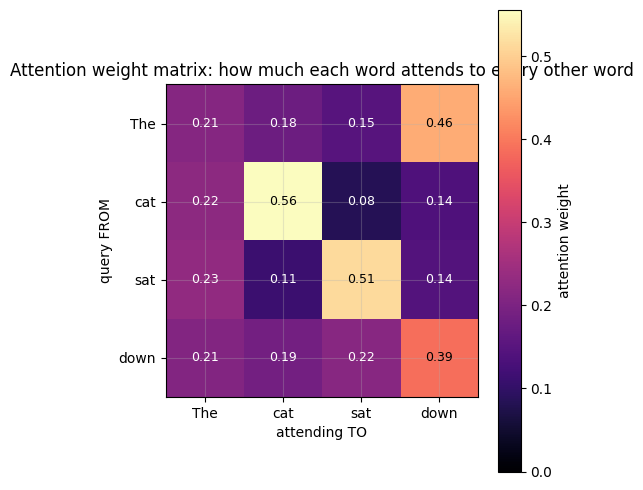

In [18]:

fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(weights, cmap='magma', vmin=0, vmax=weights.max())
ax.set_xticks(range(n_tokens)); ax.set_xticklabels(words)
ax.set_yticks(range(n_tokens)); ax.set_yticklabels(words)
ax.set_xlabel("attending TO"); ax.set_ylabel("query FROM")
ax.set_title("Attention weight matrix: how much each word attends to every other word")
for i in range(n_tokens):
    for j in range(n_tokens):
        ax.text(j, i, f"{weights[i,j]:.2f}", ha='center', va='center',
                 color='white' if weights[i,j]<weights.max()*0.6 else 'black', fontsize=9)
plt.colorbar(im, label='attention weight')
plt.tight_layout()
plt.show()



Every row sums to exactly 1 (softmax's guarantee) — read row by row, each word's row shows precisely how it distributes its "attention budget" across every word in the sentence, including itself.



## 14. Positional Encoding

### Intuition
Attention treats input as an unordered set — swap two tokens and the computation is identical unless order is injected explicitly. Positional encoding adds a unique, structured "fingerprint" to each position's embedding.

### The formula
$$ PE_{(pos,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad PE_{(pos,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right) $$

Every position gets a vector built from sine and cosine waves at many different frequencies. Early dimensions oscillate quickly (sensitive to small position changes); later dimensions oscillate slowly (sensitive to large-scale position).


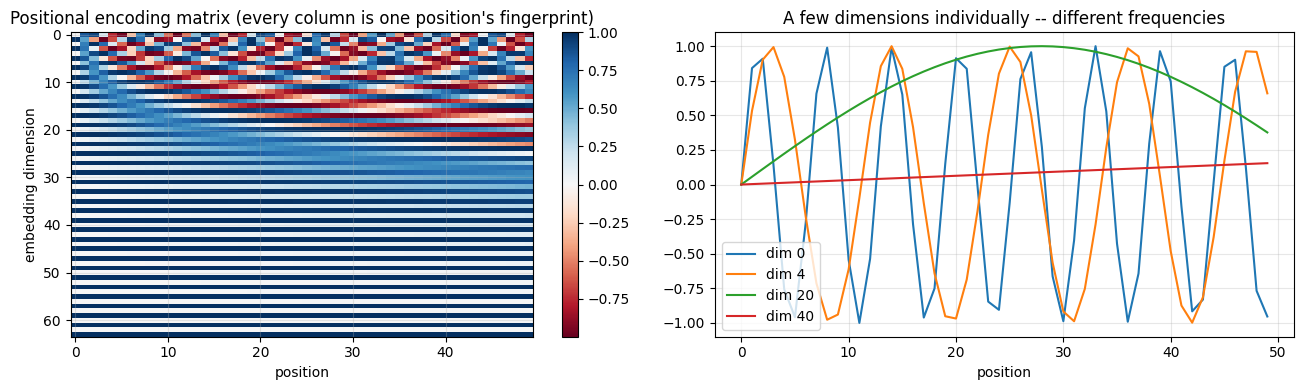

Unique position fingerprints: 50 / 50


In [19]:

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / (10000 ** (2*(i//2) / d_model))
    angles = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

seq_len, d_model = 50, 64
pe = positional_encoding(seq_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
im = axes[0].imshow(pe.T, cmap='RdBu', aspect='auto')
axes[0].set_xlabel("position"); axes[0].set_ylabel("embedding dimension")
axes[0].set_title("Positional encoding matrix (every column is one position's fingerprint)")
plt.colorbar(im, ax=axes[0])

for dim in [0, 4, 20, 40]:
    axes[1].plot(pe[:, dim], label=f"dim {dim}")
axes[1].set_xlabel("position"); axes[1].set_title("A few dimensions individually -- different frequencies")
axes[1].legend()
plt.tight_layout()
plt.show()

# sanity check: every position's encoding is unique
unique_rows = len(np.unique(pe, axis=0))
print(f"Unique position fingerprints: {unique_rows} / {seq_len}")



## 15. Graph Neural Networks

### Intuition
Every node updates itself by aggregating messages from its direct neighbors, combining that summary with its own previous state. Repeat for $k$ rounds, and every node has indirectly absorbed information from its entire $k$-hop neighborhood.

### Message passing
$$ h_v^{(k)} = \text{UPDATE}\Big(h_v^{(k-1)},\; \text{AGGREGATE}\big(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\big)\Big) $$

Aggregation (mean/sum/max) must be **permutation-invariant** — a node's neighbors have no natural order, so the result cannot depend on the order they happen to be listed in.

Below: message passing implemented as simple matrix multiplication with a normalized adjacency matrix (this is exactly the core of a GCN layer).


In [20]:

# A tiny 6-node graph
nodes = ['A','B','C','D','E','F']
edges = [('A','B'),('A','D'),('B','C'),('B','D'),('D','E'),('C','F'),('D','F')]
n = len(nodes)
idx = {name:i for i,name in enumerate(nodes)}

A = np.zeros((n,n))
for a,b in edges:
    A[idx[a], idx[b]] = 1
    A[idx[b], idx[a]] = 1
A_hat = A + np.eye(n)                      # add self-loops (a node is its own neighbor too)
D_hat = np.diag(A_hat.sum(axis=1))         # degree matrix
D_inv_sqrt = np.diag(1/np.sqrt(np.diag(D_hat)))
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt   # symmetric normalization, the GCN propagation rule

# random initial node features
rng = np.random.RandomState(9)
H0 = rng.randn(n, 3)

def gcn_layer(H, A_norm, W):
    return np.tanh(A_norm @ H @ W)

W1 = rng.randn(3, 3)*0.6
H1 = gcn_layer(H0, A_norm, W1)   # 1-hop: every node has now absorbed its direct neighbors
H2 = gcn_layer(H1, A_norm, W1)   # 2-hop: every node has now absorbed neighbors-of-neighbors

print("Initial features for node D:", np.round(H0[idx['D']], 3))
print("After 1 round of message passing:", np.round(H1[idx['D']], 3))
print("After 2 rounds of message passing:", np.round(H2[idx['D']], 3))

# permutation invariance check: shuffle neighbor order in the adjacency row, mean-aggregate, compare
neighbor_feats = H0[[idx['A'], idx['B'], idx['F']]]
mean_in_order = neighbor_feats.mean(axis=0)
shuffled = neighbor_feats[[2,0,1]]
mean_shuffled = shuffled.mean(axis=0)
print("\nMean aggregation, original order:", np.round(mean_in_order,4))
print("Mean aggregation, shuffled order: ", np.round(mean_shuffled,4), " <- identical, as required")


Initial features for node D: [-0.648  0.636  1.74 ]
After 1 round of message passing: [0.097 0.308 0.199]
After 2 rounds of message passing: [-0.011  0.059  0.043]

Mean aggregation, original order: [ 0.1397  0.2916 -0.8326]
Mean aggregation, shuffled order:  [ 0.1397  0.2916 -0.8326]  <- identical, as required



## 16. Siamese Networks & Triplet Loss

### Intuition
Feed two inputs through the *same* network (shared weights) to get two embeddings, and measure their distance. Similar pairs should end up close together; different pairs should end up far apart.

### Contrastive loss
$$ \mathcal{L} = (1-y)\,D^2 + y\,\max(0,\, m - D)^2, \qquad D = \lVert f(x_1)-f(x_2) \rVert $$

### Triplet loss
$$ \mathcal{L} = \max\big(0,\; d(a,p) - d(a,n) + \text{margin}\big) $$

Rather than an absolute distance target, triplet loss only asks for the right *order*: the negative should be farther from the anchor than the positive is, by some margin.

Below: a direct gradient-descent optimization of embedding positions using triplet loss, watched as the points physically move.


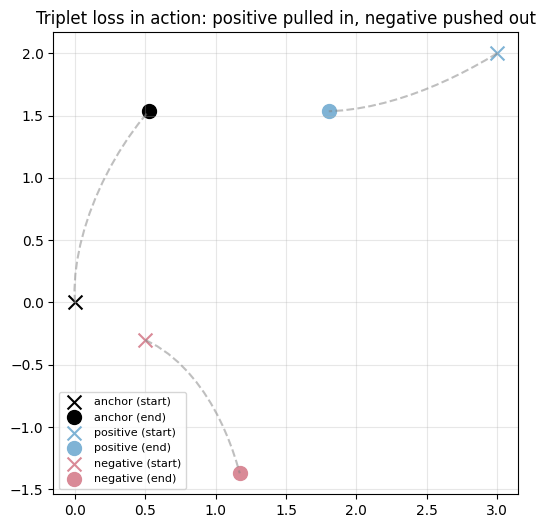

Final d(anchor,positive) = 1.279
Final d(anchor,negative) = 2.978
Margin satisfied (d_an - d_ap >= 1.5): 1.700 >= 1.5 -> True


In [21]:

# Start with an anchor, a positive (should be close), and a negative (should be far)
# as points in a 2D "embedding space", then optimize their positions directly with
# triplet loss gradients -- this isolates exactly what the loss does, independent
# of any particular network architecture.
anchor = np.array([0.0, 0.0])
positive = np.array([3.0, 2.0])
negative = np.array([0.5, -0.3])   # starts suspiciously close to the anchor
margin = 1.5
lr = 0.1

history = [np.array([anchor, positive, negative])]
for step in range(150):
    d_ap = np.linalg.norm(anchor - positive)
    d_an = np.linalg.norm(anchor - negative)
    loss = max(0, d_ap - d_an + margin)
    if loss > 0:
        # gradients of the triplet loss w.r.t. each point (via the chain rule through the norm)
        grad_ap = (anchor - positive) / (d_ap + 1e-8)
        grad_an = (anchor - negative) / (d_an + 1e-8)
        anchor   -= lr * (grad_ap - grad_an)
        positive -= lr * (-grad_ap)
        negative -= lr * (grad_an)
    history.append(np.array([anchor.copy(), positive.copy(), negative.copy()]))

history = np.array(history)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(history[:,0,0], history[:,0,1], '--', color='gray', alpha=0.5)
ax.plot(history[:,1,0], history[:,1,1], '--', color='gray', alpha=0.5)
ax.plot(history[:,2,0], history[:,2,1], '--', color='gray', alpha=0.5)
ax.scatter(*history[0,0], c='black', marker='x', s=100, label='anchor (start)')
ax.scatter(*history[-1,0], c='black', s=100, label='anchor (end)')
ax.scatter(*history[0,1], c='#7fb3d5', marker='x', s=100, label='positive (start)')
ax.scatter(*history[-1,1], c='#7fb3d5', s=100, label='positive (end)')
ax.scatter(*history[0,2], c='#d98a97', marker='x', s=100, label='negative (start)')
ax.scatter(*history[-1,2], c='#d98a97', s=100, label='negative (end)')
ax.set_title("Triplet loss in action: positive pulled in, negative pushed out")
ax.legend(fontsize=8)
plt.show()

final_d_ap = np.linalg.norm(history[-1,0]-history[-1,1])
final_d_an = np.linalg.norm(history[-1,0]-history[-1,2])
print(f"Final d(anchor,positive) = {final_d_ap:.3f}")
print(f"Final d(anchor,negative) = {final_d_an:.3f}")
print(f"Margin satisfied (d_an - d_ap >= {margin}): {final_d_an - final_d_ap:.3f} >= {margin} -> {final_d_an-final_d_ap >= margin}")



## 17. Capsule Networks

### Intuition
A capsule outputs a **vector**, not a single number: its length encodes the probability a feature exists, its direction encodes the feature's pose. Max-pooling (used in ordinary CNNs) keeps only the strongest activation and throws away exactly where and how a feature was oriented — capsules preserve that pose information.

### The squashing function
$$ v_j = \frac{\lVert s_j \rVert^2}{1+\lVert s_j \rVert^2}\cdot \frac{s_j}{\lVert s_j \rVert} $$

Squashing keeps a vector's length between 0 and 1 (interpretable as a probability) **without discarding its direction**, unlike a scalar sigmoid.

### Dynamic routing
$$ c_{ij} = \text{softmax}_j(b_{ij}), \qquad b_{ij} \leftarrow b_{ij} + \hat u_{j|i} \cdot v_j $$

Lower capsules "vote" for a higher capsule's pose; votes that agree (point the same direction) reinforce each other's coupling strength over a few iterations — routing by agreement, not by a fixed pooling rule.


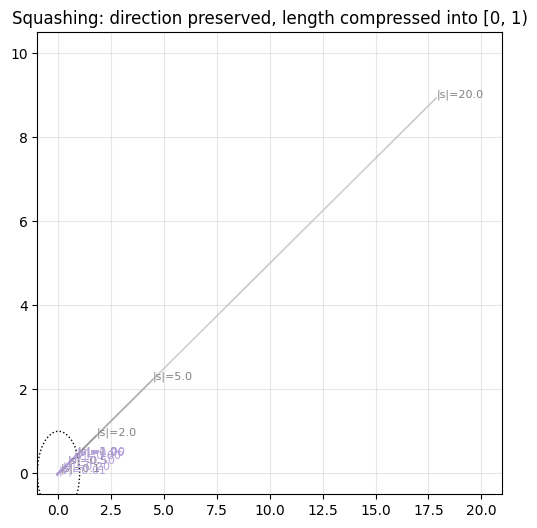

Input lengths: [0.1, 0.5, 1.0, 2.0, 5.0, 20.0]
Output lengths after squash: [np.float64(0.0099), np.float64(0.2), np.float64(0.5), np.float64(0.8), np.float64(0.9615), np.float64(0.9975)]
-> All outputs approach 1.0 but never reach it, exactly like a vector-valued sigmoid.


In [22]:

def squash(s):
    norm_sq = np.sum(s**2)
    norm = np.sqrt(norm_sq)
    return (norm_sq / (1 + norm_sq)) * (s / (norm + 1e-8))

# Show what squash does to vectors of different lengths but the same direction
directions = np.array([1.0, 0.5])
directions = directions / np.linalg.norm(directions)
lengths = [0.1, 0.5, 1.0, 2.0, 5.0, 20.0]

fig, ax = plt.subplots(figsize=(6,6))
for L in lengths:
    s = directions * L
    v = squash(s)
    ax.arrow(0, 0, s[0], s[1], color='gray', alpha=0.3, width=0.01, length_includes_head=True)
    ax.arrow(0, 0, v[0], v[1], color='#b39ddb', width=0.02, length_includes_head=True)
    ax.annotate(f"|s|={L}", (s[0], s[1]), fontsize=8, color='gray')
    ax.annotate(f"|v|={np.linalg.norm(v):.2f}", (v[0], v[1]), fontsize=8, color='#b39ddb')

circle = plt.Circle((0,0), 1.0, fill=False, linestyle=':', color='black')
ax.add_patch(circle)
ax.set_xlim(-1, 21); ax.set_ylim(-0.5, 10.5)
ax.set_title("Squashing: direction preserved, length compressed into [0, 1)")
plt.show()

print("Input lengths:", lengths)
print("Output lengths after squash:", [round(np.linalg.norm(squash(directions*L)), 4) for L in lengths])
print("-> All outputs approach 1.0 but never reach it, exactly like a vector-valued sigmoid.")



## 18. Diffusion Models

### Intuition
Take real data and add a little Gaussian noise, repeatedly, until nothing recognizable remains. Train a network to predict the noise that was added at each step; subtracting a small predicted amount of noise, repeated many times, turns pure static back into something structured.

### The forward (noising) process
$$ x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0,I) $$

This needs no learning — it's a fixed, known recipe. Below: a 1D signal, progressively noised exactly per this formula, then a simple denoising step reversing a little of that noise.


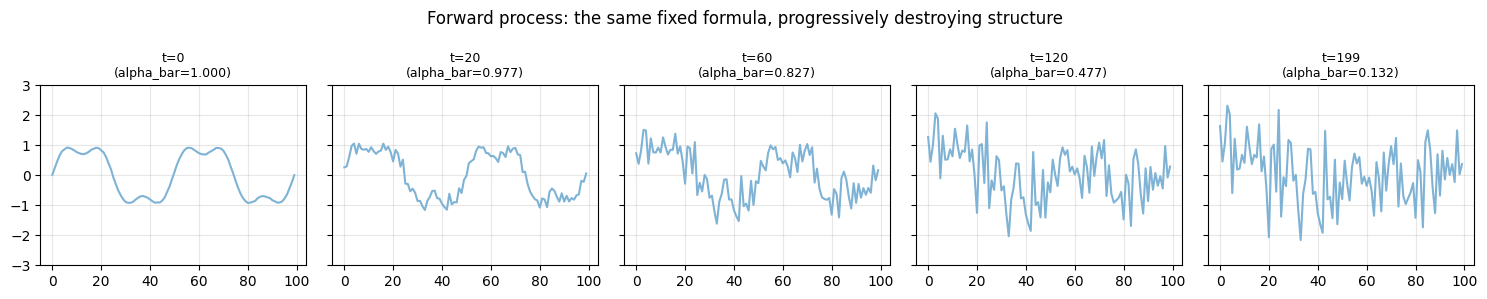

As t increases, alpha_bar shrinks toward 0:
  alpha_bar[0] = 0.9999  (almost pure signal)
  alpha_bar[100] = 0.5964
  alpha_bar[199] = 0.1322  (almost pure noise)


In [23]:

def noise_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = np.linspace(beta_start, beta_end, T)
    alphas = 1 - betas
    alpha_bars = np.cumprod(alphas)
    return alpha_bars

T = 200
alpha_bars = noise_schedule(T)

# a simple 1D "signal" (stand-in for a data point)
t_axis = np.linspace(0, 4*np.pi, 100)
x0 = np.sin(t_axis) + 0.3*np.sin(3*t_axis)

fig, axes = plt.subplots(1, 5, figsize=(15,3), sharey=True)
snapshot_steps = [0, 20, 60, 120, 199]
rng = np.random.RandomState(0)
eps = rng.randn(*x0.shape)

for ax, t in zip(axes, snapshot_steps):
    ab = alpha_bars[t]
    x_t = np.sqrt(ab)*x0 + np.sqrt(1-ab)*eps
    ax.plot(x_t, color='#7fb3d5')
    ax.set_title(f"t={t}\n(alpha_bar={ab:.3f})", fontsize=9)
    ax.set_ylim(-3,3)
plt.suptitle("Forward process: the same fixed formula, progressively destroying structure")
plt.tight_layout()
plt.show()

print("As t increases, alpha_bar shrinks toward 0:")
print("  alpha_bar[0] =", round(alpha_bars[0],4), " (almost pure signal)")
print("  alpha_bar[100] =", round(alpha_bars[100],4))
print("  alpha_bar[199] =", round(alpha_bars[199],4), " (almost pure noise)")



## 19. Closing Synthesis

Strip away the architecture-specific names, and nearly every model in this notebook reduces to the same short list of operations, reused and recombined:

| Operation | Where you saw it |
|---|---|
| **Weighted sum** ($w\cdot x + b$) | Perceptron, every layer of the MLP, the "Q, K, V" projections in attention |
| **Non-linear squashing** (sigmoid, tanh, ReLU, softmax) | Activation functions, gates in LSTM/GRU, attention weights, capsule squashing |
| **The chain rule, applied repeatedly** | Backpropagation, in literally every trainable model above |
| **A small step against the gradient** | Every single training loop in this notebook, from the perceptron to the GAN |
| **An additive shortcut around a multiplicative chain** | LSTM's cell state, (and — not shown here — ResNet's skip connections, Transformer's residual connections) |
| **Compare two things via distance or similarity** | Siamese networks, triplet loss, and the dot products inside attention itself |

**Feynman's test, one more time:** if you can rebuild any one of the code cells above from a blank notebook — not copy it, rebuild the *idea* — you understand that piece of math, not just its name.
